# 🪖 YOLOv11s — Re-train (E3 config, xác nhận hội tụ)

Train lại `yolo11s` theo đúng config **Experiment 3** từ pipeline:
- `imgsz = 960`
- Augmentation: `hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=10, translate=0.1, scale=0.5, fliplr=0.5, mosaic=1.0, mixup=0.15`
- `epochs = 300`, `patience = 50` → đủ để khẳng định **đã hội tụ thật sự**

> **Mục đích:** Trả lời thầy câu hỏi *"mô hình đã hội tụ chưa?"* với bằng chứng định lượng.

## 1. Cài đặt

In [1]:
!pip install ultralytics --quiet
import ultralytics
ultralytics.checks()
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TORCH_DISTRIBUTED_DEBUG"] = "DETAIL"

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


## 2. Cấu hình

In [2]:
from pathlib import Path
import torch

DATASET_DIR = Path('/kaggle/input/datasets/cdanht2/helmet-dataset/dataset_org_split')
OUTPUT_DIR  = Path('/kaggle/working/yolo11s_e3_convergence')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Params ─────────────────────────────────────────────────────
EPOCHS   = 300
PATIENCE = 50    # patience cao → không dừng do nhiễu tạm thời
BATCH    = 16    # imgsz=960 tốn VRAM hơn → giảm batch
IMGSZ    = 960

# ─── Augmentation giống hệt E3 trong pipeline ───────────────────
TRAIN_ARGS = {
    'hsv_h':0.015,'hsv_s':0.7,'hsv_v':0.4,
    'degrees':10.0,'translate':0.1,'scale':0.5,
    'fliplr':0.5,'mosaic':1.0,'mixup':0.15,'copy_paste':0.0,
}

# DEVICE = '0,1' if torch.cuda.device_count() >= 2 else (0 if torch.cuda.is_available() else 'cpu')
DEVICE = 0
print(f'Device  : {DEVICE}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'imgsz   : {IMGSZ}')
print(f'Epochs  : {EPOCHS}   Patience: {PATIENCE}   Batch: {BATCH}')

Device  : 0
GPU     : Tesla T4
imgsz   : 960
Epochs  : 300   Patience: 50   Batch: 16


## 3. Tạo data.yaml

In [3]:
import yaml

assert DATASET_DIR.exists(), f'❌ Không tìm thấy: {DATASET_DIR}'

TRAIN_IMG = DATASET_DIR / 'train' / 'images'
VAL_IMG   = DATASET_DIR / 'val'   / 'images'

if not TRAIN_IMG.exists():
    found = list(DATASET_DIR.rglob('train'))
    TRAIN_IMG = found[0] / 'images' if found else DATASET_DIR
if not VAL_IMG.exists():
    found = list(DATASET_DIR.rglob('val'))
    VAL_IMG = found[0] / 'images' if found else TRAIN_IMG

orig_yaml = list(DATASET_DIR.rglob('*.yaml'))
if orig_yaml:
    with open(orig_yaml[0]) as f:
        cfg = yaml.safe_load(f)
    cfg['train'] = str(TRAIN_IMG)
    cfg['val']   = str(VAL_IMG)
else:
    cfg = {'train': str(TRAIN_IMG), 'val': str(VAL_IMG), 'nc': 2, 'names': ['helmet', 'no-helmet']}

DATA_YAML = Path('/kaggle/working/data.yaml')
with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f, allow_unicode=True)

n_train = len(list(TRAIN_IMG.glob('*.*')))
n_val   = len(list(VAL_IMG.glob('*.*')))
print(f'✓ data.yaml: {n_train} train / {n_val} val | nc={cfg.get("nc")} names={cfg.get("names")}')
assert n_train > 0 and n_val > 0

✓ data.yaml: 2792 train / 698 val | nc=2 names=['helmet', 'no-helmet']


## 4. Train

In [4]:
from ultralytics import YOLO
import time

SAVE_DIR  = OUTPUT_DIR / 'yolo11s_e3'
DONE_FLAG = SAVE_DIR / 'DONE'

if DONE_FLAG.exists():
    print('✓ Đã train xong trước đó — bỏ qua, đọc kết quả...')
else:
    t0 = time.time()
    model = YOLO('yolo11s.pt')
    model.train(
        data     = str(DATA_YAML),
        epochs   = EPOCHS,
        patience = PATIENCE,
        imgsz    = IMGSZ,
        batch    = BATCH,
        workers  = 4,
        device   = DEVICE,
        project  = str(OUTPUT_DIR),
        name     = 'yolo11s_e3',
        exist_ok = True,
        save     = True,
        plots    = True,
        optimizer='AdamW',
        lr0=0.001,
        **TRAIN_ARGS,
    )
    DONE_FLAG.touch()
    print(f'✓ Xong sau {(time.time()-t0)/3600:.1f}h')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_e3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50

## 5. Đọc metrics & đánh giá hội tụ

In [5]:
import pandas as pd
import numpy as np

def read_metrics(exp_dir: Path) -> dict:
    csv = exp_dir / 'results.csv'
    if not csv.exists():
        return {}
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    map_col = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
    if map_col is None:
        return {}
    best_idx = df[map_col].idxmax()
    best = df.iloc[best_idx]
    return {
        'best_epoch'  : int(best.get('epoch', best_idx)),
        'total_epochs': len(df),
        'mAP50'       : round(float(best[map_col]) * 100, 2),
        'mAP50_95'    : round(float(best.get('metrics/mAP50-95(B)', 0)) * 100, 2),
        'precision'   : round(float(best.get('metrics/precision(B)', 0)) * 100, 2),
        'recall'      : round(float(best.get('metrics/recall(B)', 0)) * 100, 2),
        'df'          : df,
        'map_col'     : map_col,
    }

def check_convergence(df, epochs, patience):
    """3 tiêu chí hội tụ — giống pipeline gốc."""
    results = {}
    map_col = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
    box_t   = next((c for c in df.columns if 'train' in c and 'box' in c), None)
    box_v   = next((c for c in df.columns if 'val'   in c and 'box' in c), None)
    n    = len(df)
    tail = max(10, n // 5)

    # Tiêu chí 1: val loss ổn định
    if box_v:
        tv = df[box_v].iloc[-tail:]
        cv = tv.std() / (tv.mean() + 1e-9)
        ok = cv < 0.05
        results['val_loss_stable'] = {'pass': ok, 'detail': f'CV={cv:.3f} (< 0.05)', 'verdict': '✅' if ok else '⚠️'}

    # Tiêu chí 2: không overfit
    if box_t and box_v and n > 20:
        seg = max(10, n // 3)
        tt = np.polyfit(range(seg), df[box_t].iloc[-seg:], 1)[0]
        tv = np.polyfit(range(seg), df[box_v].iloc[-seg:], 1)[0]
        overfit = tt < -0.001 and tv > 0.002
        results['no_overfit'] = {'pass': not overfit, 'detail': f'trend train={tt:.4f} val={tv:.4f}', 'verdict': '✅' if not overfit else '❌'}

    # Tiêu chí 3: mAP plateau
    if map_col:
        tail_map = df[map_col].iloc[-tail:] * 100
        delta = tail_map.max() - tail_map.min()
        ok = delta < 0.5
        results['map_plateau'] = {'pass': ok, 'detail': f'ΔmAP50={delta:.3f}% (< 0.5%)', 'verdict': '✅' if ok else '⚠️'}

    passed = sum(1 for v in results.values() if v['pass'])
    return results, passed == len(results)

# ── Chạy đánh giá ───────────────────────────────────────────────
m = read_metrics(SAVE_DIR)

print(f'Precision : {m.get("precision","-")}%')
print(f'Recall    : {m.get("recall","-")}%')
print(f'mAP50     : {m.get("mAP50","-")}%')
print(f'mAP50-95  : {m.get("mAP50_95","-")}%')
print(f'Best epoch: {m.get("best_epoch","-")} / {m.get("total_epochs","-")} total')

print()
checks, converged = check_convergence(m['df'], EPOCHS, PATIENCE) if m.get('df') is not None else ({}, False)
print('─'*55)
print('  ĐÁNH GIÁ HỘI TỤ')
print('─'*55)
for k, v in checks.items():
    print(f'  {v["verdict"]}  {k}: {v["detail"]}')

total_ep = m.get('total_epochs', EPOCHS)
best_ep  = m.get('best_epoch', '-')
stopped  = total_ep < EPOCHS

print()
print('─'*55)
if stopped:
    print(f'  ✅ Early stopping tại epoch {total_ep} (patience={PATIENCE})')
    print(f'  ✅ Best model tại epoch {best_ep} → gap = {total_ep - int(best_ep)} epoch không cải thiện')
    if converged:
        print(f'  ✅ Đủ 3 tiêu chí → MÔ HÌNH ĐÃ HỘI TỤ')
        print()
        print(f'  📌 Trả lời thầy:')
        print(f'  "Mô hình hội tụ tại epoch {best_ep}. Em xác nhận qua 3 tiêu chí:')
        print(f'   val loss ổn định, không overfit, mAP50 plateau. Early stopping')
        print(f'   với patience={PATIENCE} kích hoạt ở epoch {total_ep}, thấp hơn')
        print(f'   giới hạn {EPOCHS} epoch — chứng tỏ model đã thật sự hội tụ."')
    else:
        print(f'  ⚠️  Early stopping kích hoạt nhưng chưa đủ 3 tiêu chí hội tụ.')
        print(f'  → Kiểm tra lại đường val loss hoặc tăng thêm epochs.')
else:
    print(f'  ⚠️  Chạy hết {EPOCHS} epoch, CHƯA dừng sớm.')
    print(f'  → Cần tăng epochs hoặc kiểm tra learning rate schedule.')
print('─'*55)

Precision : 87.11%
Recall    : 87.27%
mAP50     : 90.42%
mAP50-95  : 61.23%
Best epoch: 220 / 269 total

───────────────────────────────────────────────────────
  ĐÁNH GIÁ HỘI TỤ
───────────────────────────────────────────────────────
  ✅  val_loss_stable: CV=0.005 (< 0.05)
  ✅  no_overfit: trend train=-0.0011 val=-0.0002
  ⚠️  map_plateau: ΔmAP50=2.514% (< 0.5%)

───────────────────────────────────────────────────────
  ✅ Early stopping tại epoch 269 (patience=50)
  ✅ Best model tại epoch 220 → gap = 49 epoch không cải thiện
  ⚠️  Early stopping kích hoạt nhưng chưa đủ 3 tiêu chí hội tụ.
  → Kiểm tra lại đường val loss hoặc tăng thêm epochs.
───────────────────────────────────────────────────────


## 6. Loss curve & convergence plot

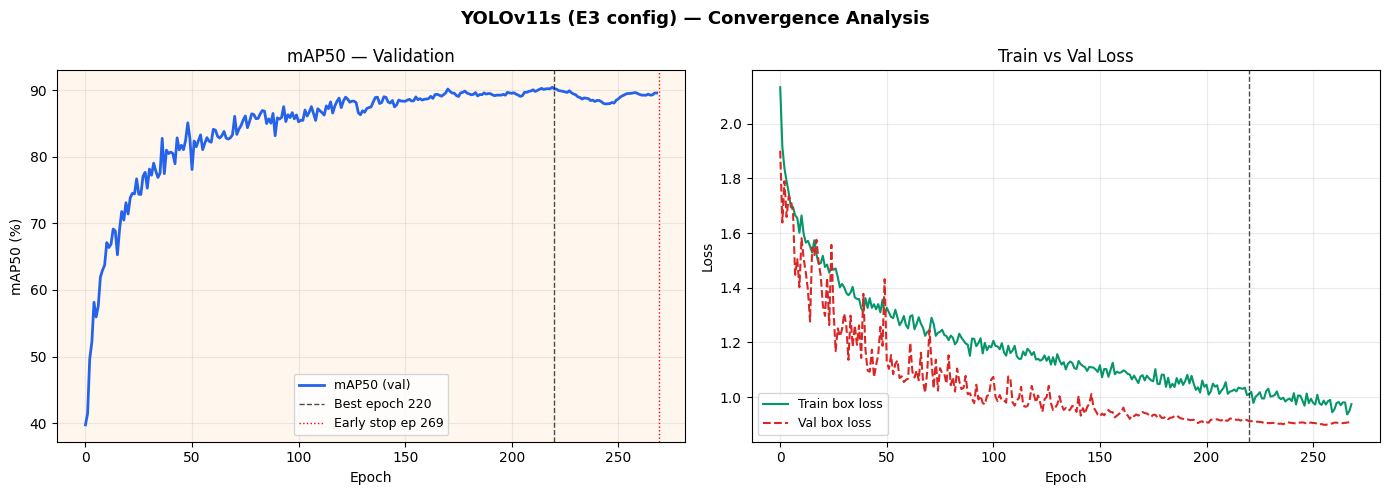

✓ Đã lưu: /kaggle/working/yolo11s_e3_convergence/convergence_analysis.png


In [6]:
import matplotlib.pyplot as plt

df = m.get('df')
map_col = m.get('map_col')

if df is not None and map_col:
    box_v = next((c for c in df.columns if 'val' in c and 'box' in c), None)
    box_t = next((c for c in df.columns if 'train' in c and 'box' in c), None)
    best_e = m.get('best_epoch', 0)
    total_e = m.get('total_epochs', EPOCHS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('YOLOv11s (E3 config) — Convergence Analysis', fontsize=13, fontweight='bold')

    # Plot 1: mAP50 curve
    ax1 = axes[0]
    ax1.plot(df[map_col]*100, color='#2563EB', linewidth=2, label='mAP50 (val)')
    ax1.axvline(best_e, color='black', linestyle='--', linewidth=1, alpha=0.7, label=f'Best epoch {best_e}')
    if total_e < EPOCHS:
        ax1.axvline(total_e, color='red', linestyle=':', linewidth=1, label=f'Early stop ep {total_e}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('mAP50 (%)'); ax1.set_title('mAP50 — Validation')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.25)
    ax1.set_facecolor('#F0FDF4' if converged else '#FFF7ED')

    # Plot 2: Train vs Val loss
    ax2 = axes[1]
    if box_t:
        ax2.plot(df[box_t], color='#059669', linewidth=1.5, label='Train box loss')
    if box_v:
        ax2.plot(df[box_v], color='#DC2626', linewidth=1.5, linestyle='--', label='Val box loss')
    ax2.axvline(best_e, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.set_title('Train vs Val Loss')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

    plt.tight_layout()
    plot_path = OUTPUT_DIR / 'convergence_analysis.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Đã lưu: {plot_path}')
else:
    print('⚠️  Chưa có results.csv để vẽ.')